# Multi-class Intrusion Detection

This notebook extends the binary intrusion detection system by classifying network traffic into five categories:

- Normal
- DoS
- Probe
- R2L
- U2R

The performance of multiple machine learning algorithms is compared using multi-class evaluation metrics.

In [2]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
column_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train = pd.read_csv("../data/raw/KDDTrain+.txt", names=column_names)
test = pd.read_csv("../data/raw/KDDTest+.txt", names=column_names)

In [4]:
attack_mapping = {

    "normal":"Normal",

    # DoS
    "back":"DoS",
    "land":"DoS",
    "neptune":"DoS",
    "pod":"DoS",
    "smurf":"DoS",
    "teardrop":"DoS",
    "apache2":"DoS",
    "mailbomb":"DoS",
    "processtable":"DoS",
    "udpstorm":"DoS",

    # Probe
    "ipsweep":"Probe",
    "nmap":"Probe",
    "portsweep":"Probe",
    "satan":"Probe",
    "mscan":"Probe",
    "saint":"Probe",

    # R2L
    "ftp_write":"R2L",
    "guess_passwd":"R2L",
    "imap":"R2L",
    "multihop":"R2L",
    "phf":"R2L",
    "spy":"R2L",
    "warezclient":"R2L",
    "warezmaster":"R2L",
    "sendmail":"R2L",
    "named":"R2L",
    "snmpgetattack":"R2L",
    "snmpguess":"R2L",
    "xlock":"R2L",
    "xsnoop":"R2L",
    "worm":"R2L",

    # U2R
    "buffer_overflow":"U2R",
    "loadmodule":"U2R",
    "perl":"U2R",
    "rootkit":"U2R",
    "httptunnel":"U2R",
    "ps":"U2R",
    "sqlattack":"U2R",
    "xterm":"U2R"
}

In [5]:
train["attack_class"] = train["label"].map(attack_mapping)
test["attack_class"] = test["label"].map(attack_mapping)

train["attack_class"].value_counts()

attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

In [6]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train["attack_class"])
y_test = label_encoder.transform(test["attack_class"])

print(label_encoder.classes_)

['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


In [7]:
X_train = train.drop(
    columns=[
        "label",
        "difficulty",
        "attack_class"
    ]
)

X_test = test.drop(
    columns=[
        "label",
        "difficulty",
        "attack_class"
    ]
)

In [8]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [9]:
results = []

def evaluate_model(name, model):

    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time()-start

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,pred)

    precision = precision_score(
        y_test,
        pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        pred,
        average="weighted"
    )

    results.append({
        "Model":name,
        "Accuracy":accuracy,
        "Precision":precision,
        "Recall":recall,
        "F1 Score":f1,
        "Train Time":train_time
    })

    print("\n",name)
    print("="*50)

    print(classification_report(
        y_test,
        pred,
        target_names=label_encoder.classes_
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=label_encoder.classes_,
        xticks_rotation=45,
        cmap="Blues"
    )

    plt.show()


 Logistic Regression
              precision    recall  f1-score   support

         DoS       0.74      0.62      0.67      7458
      Normal       0.58      0.97      0.72      9711
       Probe       0.00      0.00      0.00      2421
         R2L       0.00      0.00      0.00      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.62     22544
   macro avg       0.26      0.32      0.28     22544
weighted avg       0.49      0.62      0.54     22544



/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/diffuse/Reposit

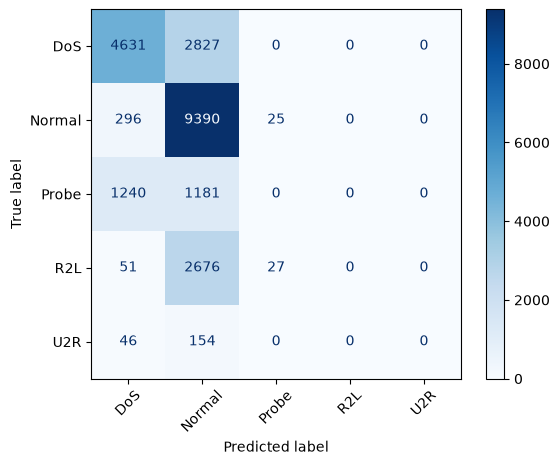

In [10]:
lr = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(max_iter=1000))
])

evaluate_model("Logistic Regression",lr)


 Decision Tree
              precision    recall  f1-score   support

         DoS       0.95      0.80      0.87      7458
      Normal       0.66      0.97      0.78      9711
       Probe       0.80      0.62      0.70      2421
         R2L       0.97      0.06      0.12      2754
         U2R       0.71      0.06      0.11       200

    accuracy                           0.76     22544
   macro avg       0.82      0.50      0.52     22544
weighted avg       0.81      0.76      0.72     22544



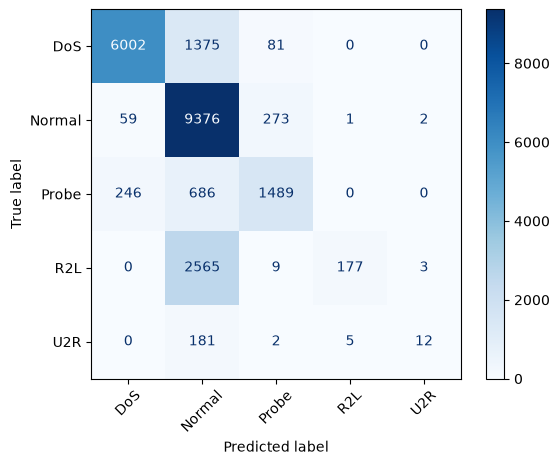

In [11]:
dt = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_split=5,
        random_state=42
    ))
])

evaluate_model("Decision Tree",dt)


 Random Forest
              precision    recall  f1-score   support

         DoS       0.96      0.75      0.84      7458
      Normal       0.64      0.97      0.77      9711
       Probe       0.82      0.60      0.69      2421
         R2L       0.98      0.06      0.11      2754
         U2R       0.71      0.03      0.05       200

    accuracy                           0.74     22544
   macro avg       0.82      0.48      0.49     22544
weighted avg       0.81      0.74      0.70     22544



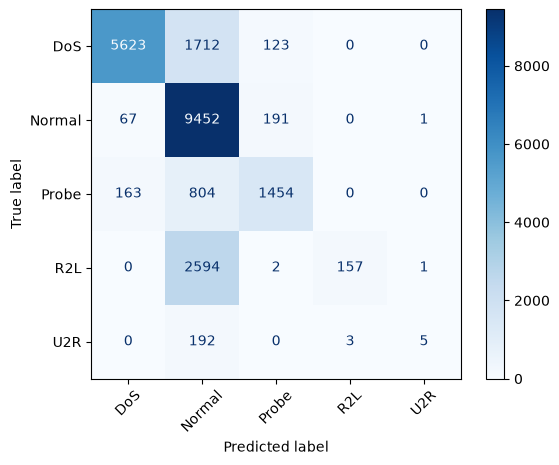

In [12]:
rf = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

evaluate_model("Random Forest",rf)


 XGBoost
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.90      7458
      Normal       0.69      0.97      0.80      9711
       Probe       0.80      0.65      0.72      2421
         R2L       0.97      0.09      0.17      2754
         U2R       0.80      0.06      0.11       200

    accuracy                           0.78     22544
   macro avg       0.84      0.52      0.54     22544
weighted avg       0.83      0.78      0.74     22544



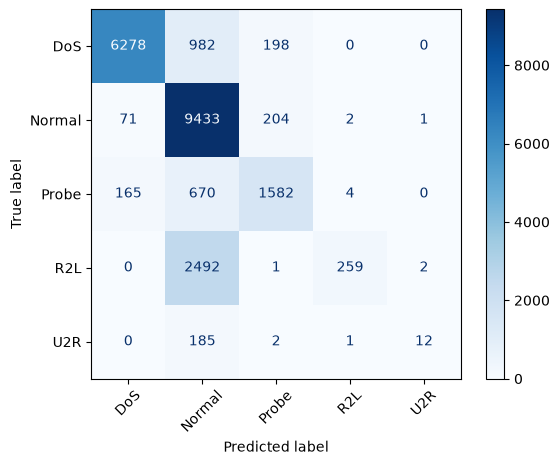

In [13]:
xgb = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

evaluate_model("XGBoost",xgb)


 LightGBM
              precision    recall  f1-score   support

         DoS       0.81      0.70      0.75      7458
      Normal       0.70      0.94      0.81      9711
       Probe       0.46      0.57      0.51      2421
         R2L       0.00      0.00      0.00      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.70     22544
   macro avg       0.40      0.44      0.41     22544
weighted avg       0.62      0.70      0.65     22544



/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


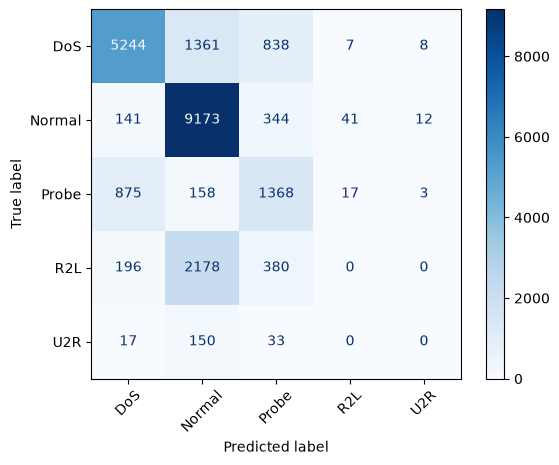

In [14]:
lgbm = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        verbose=-1
    ))
])

evaluate_model("LightGBM",lgbm)

In [15]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Train Time
3,XGBoost,0.7791,0.8256,0.7791,0.7425,4.4297
1,Decision Tree,0.7566,0.8102,0.7566,0.7171,0.8538
2,Random Forest,0.7404,0.8082,0.7404,0.7004,2.4190
4,LightGBM,0.7002,0.6211,0.7002,0.6513,3.7093
0,Logistic Regression,0.6219,0.4938,0.6219,0.5352,26.7102


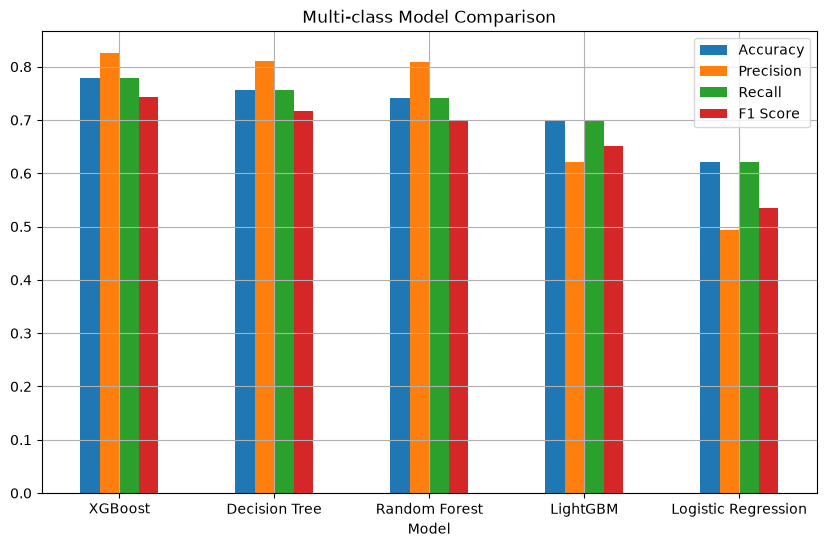

In [16]:
results_df.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score"],
    kind="bar",
    figsize=(10,6)
)

plt.grid(True)
plt.title("Multi-class Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [17]:
results_df.to_csv(
    "../reports/multiclass_results.csv",
    index=False
)

In [18]:
print("Unmapped train labels:")
print(set(train["label"]) - set(attack_mapping.keys()))

print("\nUnmapped test labels:")
print(set(test["label"]) - set(attack_mapping.keys()))

Unmapped train labels:
set()

Unmapped test labels:
set()
